In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# For saving model
import json
import pickle
import joblib
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Initial data inspection
print("\n📊 DATASET OVERVIEW:")
print("-" * 40)
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")


📊 DATASET OVERVIEW:
----------------------------------------
Number of samples: 2200
Number of features: 8

Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [4]:
print("="*60)
print("DATA EXPLORATION")
print("="*60)

print("\n📊 Data Types:")
print(df.dtypes)

print("\n🎯 Target Variable (label) Analysis:")
print(f"Unique crops: {df['label'].nunique()}")
print(f"\nCrop distribution:")
print(df['label'].value_counts())

print("\n🧮 Statistical Summary:")
display(df.describe())

print("\n🔍 Missing Values Check:")
print(df.isnull().sum())

print("\n🔍 Duplicate Rows Check:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

DATA EXPLORATION

📊 Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

🎯 Target Variable (label) Analysis:
Unique crops: 22

Crop distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

🧮 Statistical Summary:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



🔍 Missing Values Check:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

🔍 Duplicate Rows Check:
Number of duplicate rows: 0


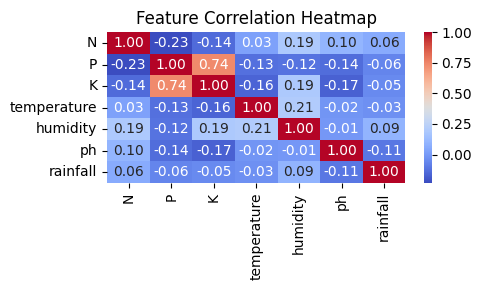

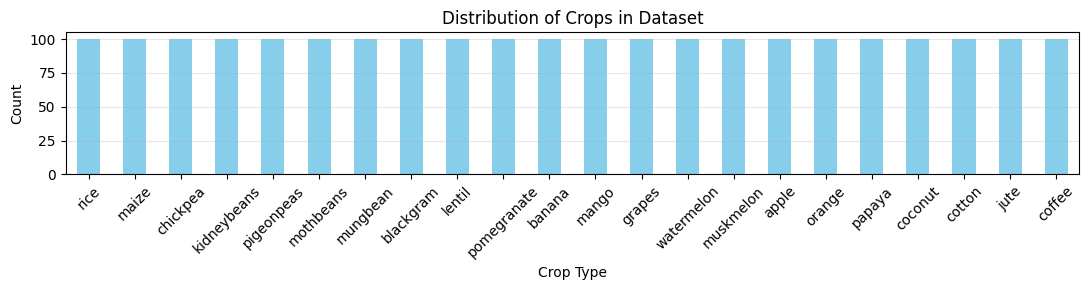

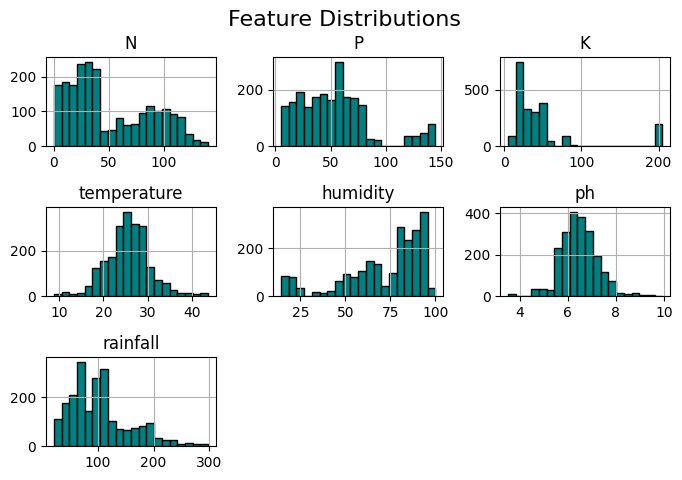

In [18]:
# 1. Correlation Heatmap (numeric columns only)
plt.figure(figsize=(5,3))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 2. Crop Distribution
plt.figure(figsize=(11,3))
df['label'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Crops in Dataset')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Feature Distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df[features].hist(bins=20, figsize=(7,5), color='teal', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

In [23]:
# Separate features and target
features = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']
labels = df['label']

print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")
print(f"\nFeature columns: {list(features.columns)}")
print(f"\nTarget classes: {target.unique()}")

Features shape: (2200, 7)
Target shape: (2200,)

Feature columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target classes: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [24]:
# Split the data
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features, target, test_size=0.2, random_state=2)

print(f"✅ Data split successfully!")
print(f"Training set: {Xtrain.shape}, {Ytrain.shape}")
print(f"Testing set: {Xtest.shape}, {Ytest.shape}")
print(f"\nTraining class distribution:")
print(Ytrain.value_counts())

✅ Data split successfully!
Training set: (1760, 7), (1760,)
Testing set: (440, 7), (440,)

Training class distribution:
label
apple          87
kidneybeans    86
watermelon     85
blackgram      84
rice           84
pomegranate    83
banana         83
pigeonpeas     82
grapes         82
papaya         81
mothbeans      81
cotton         80
maize          79
chickpea       79
coconut        79
coffee         78
lentil         77
muskmelon      77
mungbean       76
mango          74
jute           72
orange         71
Name: count, dtype: int64


In [25]:
print("="*60)
print("GAUSSIAN NAIVE BAYES MODEL")
print("="*60)

# Initialize and train model
NaiveBayes = GaussianNB()
NaiveBayes.fit(Xtrain, Ytrain)

# Make predictions
predicted_values = NaiveBayes.predict(Xtest)

# Calculate accuracy
nb_accuracy = accuracy_score(Ytest, predicted_values)
print(f"✅ Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

# Classification report
print("\n📊 Classification Report:")
print(classification_report(Ytest, predicted_values))

# Cross-validation score
print("\n🔍 Cross-Validation Score (5-fold):")
nb_cv_score = cross_val_score(NaiveBayes, features, target, cv=5)
print(f"Scores: {nb_cv_score}")
print(f"Mean CV Score: {nb_cv_score.mean():.4f}")

GAUSSIAN NAIVE BAYES MODEL
✅ Naive Bayes Accuracy: 0.9909 (99.09%)

📊 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.88      1.00      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.0

In [26]:
print("="*60)
print("RANDOM FOREST MODEL")
print("="*60)

# Initialize and train model
RF = RandomForestClassifier(n_estimators=20, random_state=5)
RF.fit(Xtrain, Ytrain)

# Make predictions
predicted_values = RF.predict(Xtest)

# Calculate accuracy
rf_accuracy = accuracy_score(Ytest, predicted_values)
print(f"✅ Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Classification report
print("\n📊 Classification Report:")
print(classification_report(Ytest, predicted_values))

# Cross-validation score
print("\n🔍 Cross-Validation Score (5-fold):")
rf_cv_score = cross_val_score(RF, features, target, cv=5)
print(f"Scores: {rf_cv_score}")
print(f"Mean CV Score: {rf_cv_score.mean():.4f}")

RANDOM FOREST MODEL
✅ Random Forest Accuracy: 0.9955 (99.55%)

📊 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.93      1.00      0.97        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00    

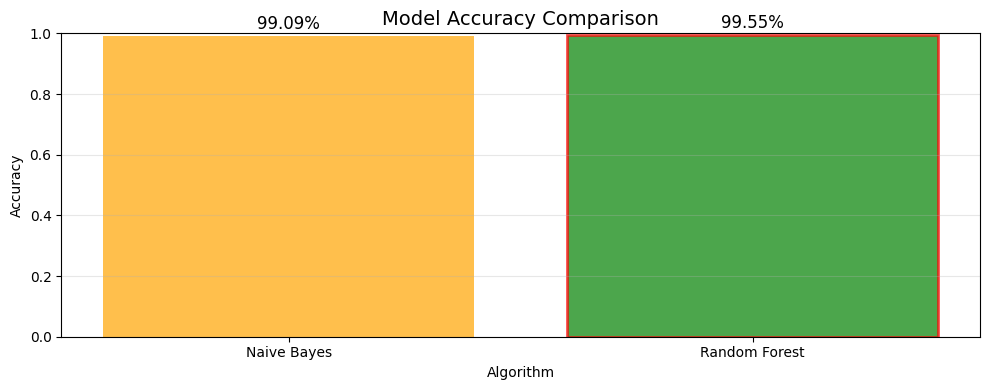


🏆 Best Model: Random Forest with 99.55% accuracy


In [32]:


# Prepare data for comparison
accuracies = [nb_accuracy, rf_accuracy]
models = ['Naive Bayes', 'Random Forest']

# Plot comparison
plt.figure(figsize=[10,4], dpi=100)
bars = plt.bar(models, accuracies, color=['orange', 'green'], alpha=0.7)

# Add accuracy percentages
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracy:.2%}', ha='center', va='bottom', fontsize=12)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

# Highlight best model
best_idx = np.argmax(accuracies)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

print(f"\n🏆 Best Model: {models[best_idx]} with {accuracies[best_idx]:.2%} accuracy")

In [ ]:

# Test cases
test_cases = [
    [104, 18, 30, 23.603016, 60.3, 6.7, 140.91],  # Should be coffee
    [83, 45, 60, 28, 70.3, 7.0, 150.9],           # Should be jute
    [101, 11, 36, 23.603016, 60.3, 6.1, 140.91],  # Should be coffee
    [90, 42, 43, 20.879744, 82.002744, 6.502985, 202.935536]  # From dataset
]

print("Testing Random Forest predictions:")  
for i, test_data in enumerate(test_cases):
    data_array = np.array([test_data])
    prediction = RF.predict(data_array)
    print(f"Test {i+1}: {test_data}")
    print(f"  → Predicted crop: {prediction[0]}")
    print()

TEST PREDICTIONS
Testing Random Forest predictions:
Test 1: [104, 18, 30, 23.603016, 60.3, 6.7, 140.91]
  → Predicted crop: coffee

Test 2: [83, 45, 60, 28, 70.3, 7.0, 150.9]
  → Predicted crop: jute

Test 3: [101, 11, 36, 23.603016, 60.3, 6.1, 140.91]
  → Predicted crop: coffee

Test 4: [90, 42, 43, 20.879744, 82.002744, 6.502985, 202.935536]
  → Predicted crop: rice



In [35]:
print("="*60)
print("FINAL MODEL TRAINING WITH ENCODED LABELS")
print("="*60)

# Prepare data with encoded labels
X = df.drop('label', axis=1)
y = df['label']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i}: {label}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"\n✅ Data prepared:")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")

# Train final Random Forest model
RF_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
RF_final.fit(X_train, y_train)

# Predictions
y_pred = RF_final.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"\n🎯 Final Random Forest Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# Test prediction with encoded labels
test_sample = np.array([[100, 18, 20, 23.603016, 20.3, 7.7, 170.91]])
pred_encoded = RF_final.predict(test_sample)
pred_label = le.inverse_transform(pred_encoded)
print(f"\n🧪 Test Prediction: {pred_label[0]} (Encoded: {pred_encoded[0]})")

FINAL MODEL TRAINING WITH ENCODED LABELS
Label Encoding Mapping:
  0: apple
  1: banana
  2: blackgram
  3: chickpea
  4: coconut
  5: coffee
  6: cotton
  7: grapes
  8: jute
  9: kidneybeans
  10: lentil
  11: maize
  12: mango
  13: mothbeans
  14: mungbean
  15: muskmelon
  16: orange
  17: papaya
  18: pigeonpeas
  19: pomegranate
  20: rice
  21: watermelon

✅ Data prepared:
Training set: (1760, 7), (1760,)
Testing set: (440, 7), (440,)

🎯 Final Random Forest Accuracy: 0.9932 (99.32%)

🧪 Test Prediction: coffee (Encoded: 5)


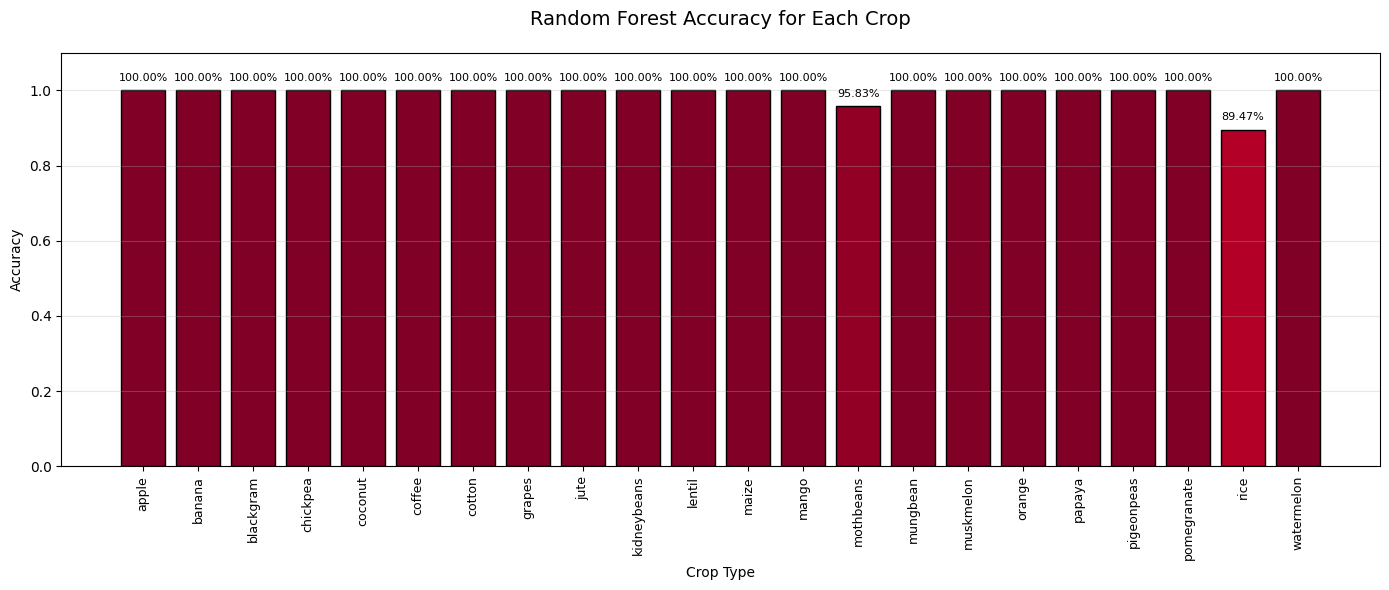


⚠️ Crops with accuracy < 90%:
  rice: 89.47%


In [37]:


# Calculate accuracy for each crop
accuracy_per_crop = []
crop_labels = le.inverse_transform(sorted(np.unique(y_test)))

for crop_label in crop_labels:
    indices = (y_test == le.transform([crop_label])[0])
    if sum(indices) > 0:  # Check if crop exists in test set
        accuracy = accuracy_score(y_test[indices], y_pred[indices])
        accuracy_per_crop.append(accuracy)
    else:
        accuracy_per_crop.append(0)

# Create visualization
plt.figure(figsize=(14, 6))

# Create color gradient based on accuracy
colors = plt.cm.YlOrRd([acc/max(accuracy_per_crop) for acc in accuracy_per_crop])

bars = plt.bar(range(len(crop_labels)), accuracy_per_crop, color=colors, edgecolor='black')

plt.title('Random Forest Accuracy for Each Crop', fontsize=14, pad=20)
plt.xlabel('Crop Type')
plt.ylabel('Accuracy')
plt.xticks(range(len(crop_labels)), crop_labels, rotation=90, fontsize=9)
plt.ylim([0, 1.1])

# Add accuracy values on bars
for bar, accuracy in zip(bars, accuracy_per_crop):
    height = bar.get_height()
    if height > 0:  # Only label if there's data
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{accuracy:.2%}', ha='center', va='bottom', fontsize=8)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print low-accuracy crops
print("\n⚠️ Crops with accuracy < 90%:")
for crop, acc in zip(crop_labels, accuracy_per_crop):
    if acc < 0.9 and acc > 0:
        print(f"  {crop}: {acc:.2%}")

In [ ]:
print("="*60)
print("SAVING MODELS FOR FLASK DEPLOYMENT")
print("="*60)

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save Random Forest model (with encoded labels)
MODEL_PATH = '../models/crop_model.pkl'
with open(MODEL_PATH, 'wb') as file:
    pickle.dump(RF_final, file)
print(f"✅ Random Forest model saved at: {MODEL_PATH}")

# Save Label Encoder
LABEL_ENCODER_PATH = '../models/crop_label_encoder.pkl'
with open(LABEL_ENCODER_PATH, 'wb') as file:
    pickle.dump(le, file)
print(f"✅ Label encoder saved at: {LABEL_ENCODER_PATH}")
print(f"   Classes: {list(le.classes_)}")

# Save feature names
FEATURE_NAMES = list(X.columns)
FEATURE_NAMES_PATH = '../models/crop_feature_names.pkl'
with open(FEATURE_NAMES_PATH, 'wb') as file:
    pickle.dump(FEATURE_NAMES, file)
print(f"✅ Feature names saved at: {FEATURE_NAMES_PATH}")
print(f"   Features: {FEATURE_NAMES}")

# Save original Random Forest model (without encoded labels) for comparison
ORIGINAL_MODEL_PATH = '../models/crop_model_original.pkl'
with open(ORIGINAL_MODEL_PATH, 'wb') as file:
    pickle.dump(RF, file)
print(f"✅ Original model (string labels) saved at: {ORIGINAL_MODEL_PATH}")

# Create model info file
MODEL_INFO = {
    'model_type': 'RandomForestClassifier',
    'accuracy': float(final_accuracy),
    'n_estimators': RF_final.n_estimators,
    'features': FEATURE_NAMES,
    'n_classes': len(le.classes_),
    'classes': list(le.classes_),
    'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

INFO_PATH = '../models/crop_model_info.json'
with open(INFO_PATH, 'w') as file:
    json.dump(MODEL_INFO, file, indent=2)
print(f"✅ Model info saved at: {INFO_PATH}")

print("\n" + "="*60)
print("🎉 CROP RECOMMENDATION MODEL TRAINING COMPLETE!")
print("="*60)

In [40]:
print("="*60)
print("SAVING MODELS FOR FLASK DEPLOYMENT")
print("="*60)

# Your specific model save path
MODEL_SAVE_PATH = "E:/SPACE INF/soil-health-project/models/"

# Create directory if it doesn't exist
import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# 1. Save Random Forest model (with encoded labels)
crop_model_path = os.path.join(MODEL_SAVE_PATH, "crop_model.pkl")
with open(crop_model_path, 'wb') as file:
    pickle.dump(RF_final, file)
print(f"✅ Random Forest model saved at: {crop_model_path}")

# 2. Save Label Encoder
label_encoder_path = os.path.join(MODEL_SAVE_PATH, "crop_label_encoder.pkl")
with open(label_encoder_path, 'wb') as file:
    pickle.dump(le, file)
print(f"✅ Label encoder saved at: {label_encoder_path}")
print(f"   Classes: {list(le.classes_)}")

# 3. Save feature names
FEATURE_NAMES = list(X.columns)
feature_names_path = os.path.join(MODEL_SAVE_PATH, "crop_feature_names.pkl")
with open(feature_names_path, 'wb') as file:
    pickle.dump(FEATURE_NAMES, file)
print(f"✅ Feature names saved at: {feature_names_path}")
print(f"   Features: {FEATURE_NAMES}")

# 4. Save original Random Forest model (without encoded labels) for comparison
original_model_path = os.path.join(MODEL_SAVE_PATH, "crop_model_original.pkl")
with open(original_model_path, 'wb') as file:
    pickle.dump(RF, file)
print(f"✅ Original model (string labels) saved at: {original_model_path}")

# 5. Create model info file
MODEL_INFO = {
    'model_type': 'RandomForestClassifier',
    'accuracy': float(final_accuracy),
    'n_estimators': RF_final.n_estimators,
    'features': FEATURE_NAMES,
    'n_classes': len(le.classes_),
    'classes': list(le.classes_),
    'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_path': crop_model_path,
    'encoder_path': label_encoder_path
}

info_path = os.path.join(MODEL_SAVE_PATH, "crop_model_info.json")
with open(info_path, 'w') as file:
    json.dump(MODEL_INFO, file, indent=2)
print(f"✅ Model info saved at: {info_path}")

print("\n" + "="*60)
print("🎉 CROP RECOMMENDATION MODEL TRAINING COMPLETE!")
print(f"📁 All files saved to: {MODEL_SAVE_PATH}")
print("="*60)

SAVING MODELS FOR FLASK DEPLOYMENT
✅ Random Forest model saved at: E:/SPACE INF/soil-health-project/models/crop_model.pkl
✅ Label encoder saved at: E:/SPACE INF/soil-health-project/models/crop_label_encoder.pkl
   Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
✅ Feature names saved at: E:/SPACE INF/soil-health-project/models/crop_feature_names.pkl
   Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
✅ Original model (string labels) saved at: E:/SPACE INF/soil-health-project/models/crop_model_original.pkl
✅ Model info saved at: E:/SPACE INF/soil-health-project/models/crop_model_info.json

🎉 CROP RECOMMENDATION MODEL TRAINING COMPLETE!
📁 All files saved to: E:/SPACE INF/soil-health-project/models/
